In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights
from torch.cuda.amp import autocast, GradScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

###################################
# Data Paths
###################################
dataset_path = "/kaggle/input/datasets/sallyibrahim/skin-cancer-isic-2019-2020-malignant-or-benign/skin_dataset_resized"

###################################
# Transforms / Augmentations
###################################
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=10, translate=(0.05,0.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

###################################
# Datasets / Dataloaders
###################################
train_dataset = ImageFolder(root=f"{dataset_path}/train_set", transform=train_transform)
val_dataset   = ImageFolder(root=f"{dataset_path}/val_set", transform=val_transform)
test_dataset  = ImageFolder(root=f"{dataset_path}/test_set", transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)


Using device: cuda


In [2]:
train_loader

In [3]:
# Class Weights (for imbalance)
###################################
labels = [label for _, label in train_dataset.samples]
class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

###################################
# Model
###################################
weights = EfficientNet_B4_Weights.DEFAULT
model = efficientnet_b4(weights=weights)
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 2)  # 2 classes
model = model.to(DEVICE)

###################################
# Loss, Optimizer, Scheduler
###################################
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
scaler = GradScaler()


Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 202MB/s]
/tmp/ipykernel_24/1980634026.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [4]:

###################################
# Training Loop with Early Stopping
###################################
from torch import amp
EPOCHS = 30
best_val_acc = 0
early_stop_counter = 0
PATIENCE = 7

train_losses, val_losses, train_accs, val_accs = [], [], [], []

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct = 0.0, 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} - Training"):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with amp.autocast(device_type='cuda'):
                 outputs = model(images)
                 loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item()*images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()

    train_loss = running_loss / len(train_dataset)
    train_acc = correct / len(train_dataset)

    # Validation
    model.eval()
    val_running_loss, val_correct = 0.0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)
            val_running_loss += loss.item()*images.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            all_preds.extend(outputs.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = val_running_loss / len(val_dataset)
    val_acc = val_correct / len(val_dataset)

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"\nEpoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # Early Stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "efficientnetb4_isic_best.pth")
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= PATIENCE:
            print("Early stopping triggered.")
            break

print(f"\nTraining complete. Best Validation Accuracy: {best_val_acc:.4f}")



Epoch 1/30 - Training: 100%|██████████| 288/288 [01:21<00:00,  3.53it/s]
/tmp/ipykernel_24/4233717066.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



Epoch [1/30] | Train Loss: 0.3951, Train Acc: 0.8838 | Val Loss: 0.3496, Val Acc: 0.9082


Epoch 2/30 - Training: 100%|██████████| 288/288 [01:07<00:00,  4.26it/s]



Epoch [2/30] | Train Loss: 0.3385, Train Acc: 0.9221 | Val Loss: 0.2960, Val Acc: 0.9473


Epoch 3/30 - Training: 100%|██████████| 288/288 [01:11<00:00,  4.04it/s]


...


Epoch [7/30] | Train Loss: 0.2813, Train Acc: 0.9534 | Val Loss: 0.3074, Val Acc: 0.9373


Epoch 8/30 - Training: 100%|██████████| 288/288 [01:10<00:00,  4.06it/s]



Epoch [8/30] | Train Loss: 0.2746, Train Acc: 0.9611 | Val Loss: 0.2914, Val Acc: 0.9427


Epoch 9/30 - Training: 100%|██████████| 288/288 [01:11<00:00,  4.03it/s]



Epoch [9/30] | Train Loss: 0.2701, Train Acc: 0.9623 | Val Loss: 0.2906, Val Acc: 0.9464
Early stopping triggered.

Training complete. Best Validation Accuracy: 0.9473


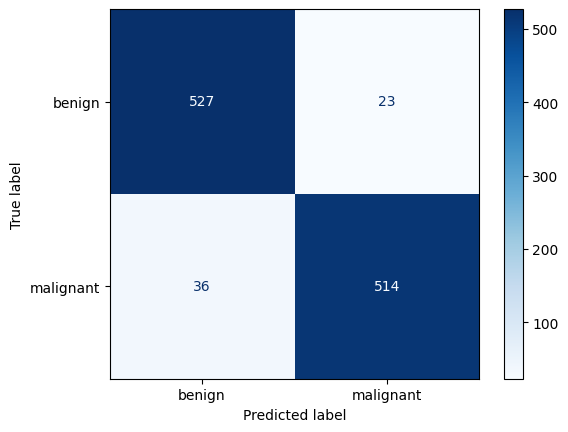

              precision    recall  f1-score   support

      benign       0.94      0.96      0.95       550
   malignant       0.96      0.93      0.95       550

    accuracy                           0.95      1100
   macro avg       0.95      0.95      0.95      1100
weighted avg       0.95      0.95      0.95      1100



In [5]:
# Confusion Matrix + Classification Report
###################################
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=val_dataset.classes)
disp.plot(cmap=plt.cm.Blues)
plt.show()

print(classification_report(all_labels, all_preds, target_names=val_dataset.classes))